In [1]:
# Version for filename
ver = 'GRU'  # GRU or LSTM

date = "250804"
rnn_folder = f"D:/Python_TK_3/datas/{date}_DL"

shap_number = "SsStim_evoked_02"
#os.mkdir(f"{rnn_folder}/shap{shap_number}")

In [2]:
import numpy as np

input_train = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_cnn_train_features.npy")
trainY = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_train_targets.npy")
input_valid = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_cnn_valid_features.npy")
validY = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_valid_targets.npy")
input_test  = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_cnn_test_features.npy")
testY  = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_test_targets.npy")

print(input_train.shape, trainY.shape)
print(input_valid.shape, validY.shape)
print(input_test.shape, testY.shape)

(2160, 11, 67584) (2160,)
(720, 11, 67584) (720,)
(720, 11, 67584) (720,)


In [2]:
import numpy as np

input_train = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_train_features.npy")
trainY      = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_train_targets.npy")

input_valid = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_valid_features.npy", )
validY      = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_valid_targets.npy")

input_test  = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_test_features.npy")
testY       = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_test_targets.npy")

print(input_train.shape)
print(trainY.shape)

print(input_valid.shape)
print(validY.shape)

print(input_test.shape)
print(testY.shape)

(336, 11, 23)
(336,)
(112, 11, 23)
(112,)
(112, 11, 23)
(112,)


In [3]:
flatted_feature = input_train.reshape(input_train.shape[0], input_train.shape[1]*input_train.shape[2])
print(flatted_feature.shape)

(2160, 743424)


In [4]:
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif_numpy(X: np.ndarray) -> np.ndarray:
    """
    X: numpy array of shape (n_samples, n_features)
    return: numpy array of shape (n_features,) containing VIF values
    """
    n_features = X.shape[1]
    vif = np.zeros(n_features, dtype=float)
    for i in range(n_features):
        vif[i] = variance_inflation_factor(X, i)
    return vif

# --- 使い方例 ---
# X が shape=(n_samples, 242) の numpy 配列の場合
vif_array = compute_vif_numpy(flatted_feature)
#print(vif_array)         # VIF 値の numpy 配列
print(vif_array.shape)   # (242,)


(253,)


In [5]:
print(min(vif_array))
print(max(vif_array))
print(np.mean(vif_array))

0.9470061567872492
18.227557703582193
4.726022051903541


In [4]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif_time(data: np.ndarray) -> np.ndarray:
    """
    各時間フレームごとに VIF（分散インフレーション因子）を計算する。

    Parameters
    ----------
    data : np.ndarray
        shape = (n_datasets, T, R)
        n_datasets: サンプル数
        T         : タイムフレーム数
        R         : 神経領域数

    Returns
    -------
    vif_array : np.ndarray
        shape = (T, R)
        各時間フレーム t における各領域 i の VIF 値
    """
    n, T, R = data.shape
    vif_array = np.zeros((T, R), dtype=float)

    for t in range(T):
        # t フレーム目のデータを DataFrame 化
        df = pd.DataFrame(
            data[:, t, :],
            columns=[f"region_{i}" for i in range(R)]
        )
        # 各列 i について VIF を計算
        vif_array[t, :] = [
            variance_inflation_factor(df.values, i)
            for i in range(R)
        ]

    return vif_array

# 使い方の例
# data = np.random.randn(100, 11, 22)  # サンプル数100、11フレーム、22領域 のダミーデータ
# vif_results = compute_vif_time(data)
# print(vif_results.shape)  # → (11, 22)
# print(vif_results)        # 各時間フレームごとの VIF 行列


In [ ]:
vif_array_2d = compute_vif_time(input_train)
print(vif_array_2d.shape)

c:\Users\user\.conda\envs\deepshap\lib\site-packages\statsmodels\regression\linear_model.py:1715: RuntimeWarning: invalid value encountered in true_divide
  return 1 - self.ssr/self.centered_tss
c:\Users\user\.conda\envs\deepshap\lib\site-packages\statsmodels\regression\linear_model.py:1715: RuntimeWarning: divide by zero encountered in true_divide
  return 1 - self.ssr/self.centered_tss


In [8]:
print(min(vif_array_2d.reshape(-1)))
print(max(vif_array_2d.reshape(-1)))
print(np.mean(vif_array_2d.reshape(-1)))

1.6704930425064661
11.59882792991811
4.634659586568801


In [9]:
fs = 20

look_frame = 10

# 初期値
start_value = -0.5

# 増加量
increment = 1/fs

# 繰り返し回数
count = look_frame+1

# リストを生成
t = [start_value + i * increment for i in range(count)]

In [10]:
roi_number = []
for ic in range(vif_array_2d.shape[1]):
    roi_number.append(f"IC{ic+1}")

print(roi_number)

['IC1', 'IC2', 'IC3', 'IC4', 'IC5', 'IC6', 'IC7', 'IC8', 'IC9', 'IC10', 'IC11', 'IC12', 'IC13', 'IC14', 'IC15', 'IC16', 'IC17', 'IC18', 'IC19', 'IC20', 'IC21', 'IC22', 'IC23']


In [11]:
vif_array2 = vif_array.reshape(look_frame+1, int(vif_array.shape[0]/(look_frame+1)))
print(vif_array2.shape)

(11, 23)


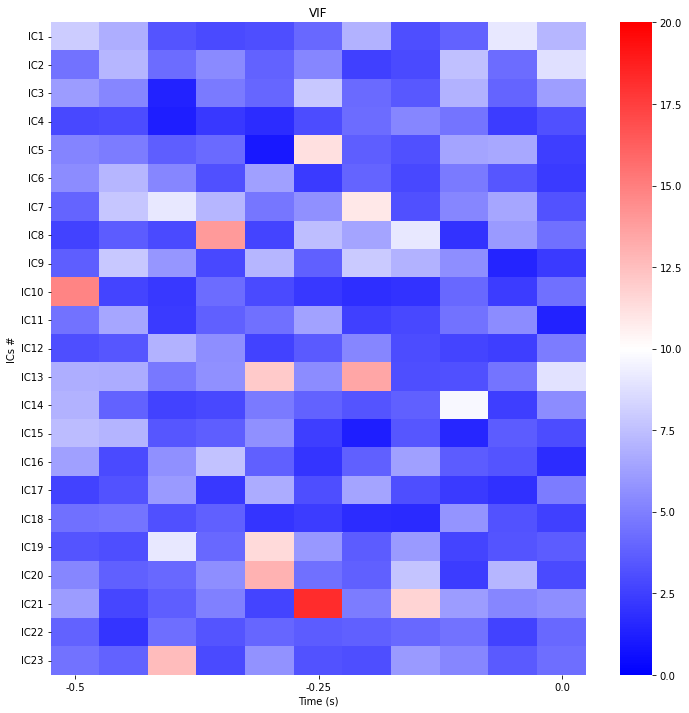

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 12))
sns.heatmap(vif_array2.transpose(), cmap='bwr', vmin=0, vmax=20)
    #plt.xticks( numpy.arange(0.5,2*look_frame+1.5), numpy.arange(-look_frame,look_frame+1), fontsize=12)
    #plt.xticks(np.arange(0.5,look_frame+1.5, 5), np.arange(-int(look_frame/fs), 1/fs, 5))
    # Tickの位置
ticks = np.arange(0.5, look_frame + 1.0, 5)
    # 同じ数のラベルを作る
labels = np.linspace(start_value, 0, len(ticks))
plt.xticks(ticks, labels)
plt.yticks( np.arange(0.5, vif_array2.shape[1]+0.5), roi_number, rotation=0)
#plt.axvspan(10.45, 10.55, color='red', alpha=1)
plt.title("VIF")
plt.xlabel("Time (s)")
plt.ylabel("ICs #")
plt.show()

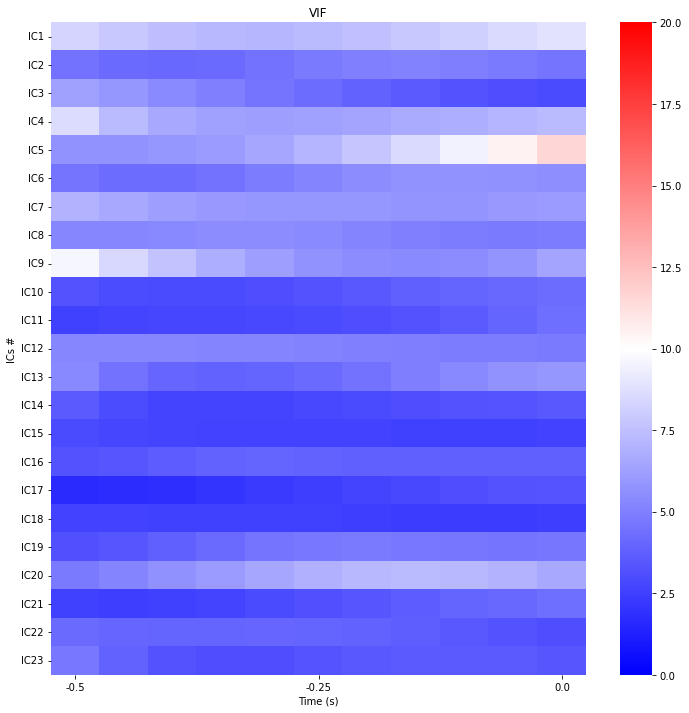

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 12))
sns.heatmap(vif_array_2d.transpose(), cmap='bwr', vmin=0, vmax=20)
    #plt.xticks( numpy.arange(0.5,2*look_frame+1.5), numpy.arange(-look_frame,look_frame+1), fontsize=12)
    #plt.xticks(np.arange(0.5,look_frame+1.5, 5), np.arange(-int(look_frame/fs), 1/fs, 5))
    # Tickの位置
ticks = np.arange(0.5, look_frame + 1.0, 5)
    # 同じ数のラベルを作る
labels = np.linspace(start_value, 0, len(ticks))
plt.xticks(ticks, labels)
plt.yticks( np.arange(0.5, vif_array_2d.shape[1]+0.5), roi_number, rotation=0)
#plt.axvspan(10.45, 10.55, color='red', alpha=1)
plt.title("VIF")
plt.xlabel("Time (s)")
plt.ylabel("ICs #")
plt.show()